In [ ]:
import datasets
ds = datasets.Dataset.from_json('../eval.json')
ds

c:\Users\anagh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 50 examples [00:00, 1675.71 examples/s]


Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores'],
    num_rows: 50
})

In [ ]:
%pip install datasets numpy scipy tqdm matplotlib

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached aiohttp-3.13.5-cp313-cp313-win_amd64.whl.metadata (8.4 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.4.1-cp313-cp313-win_amd64.whl.metadata (14 kB)
  Using cached yarl-1.23.0-cp313-cp313-win_amd64.whl.metadata (82 kB)
  Using cached click-8.3.3-py3-non

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [ ]:
import os
def map_fn(example):
    example['is_correct'] = [x==1.0 for x in example['scores']]
    return example

ds = ds.map(map_fn, num_proc=os.cpu_count())
ds

Map (num_proc=12): 100%|██████████| 50/50 [00:09<00:00,  5.10 examples/s]


Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores', 'is_correct'],
    num_rows: 50
})

In [ ]:
import numpy as np
from scipy.special import comb
from tqdm import tqdm

def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [ ]:
def calculate_pass_at_k_corrected(correctness_matrix):
    n_problems, n_samples = correctness_matrix.shape
    pass_at_k_values = []
    
    for k in range(1, n_samples + 1):
        pass_at_k_per_problem = []
        
        for problem_idx in range(n_problems):
            correct_samples = np.sum(correctness_matrix[problem_idx])
            
            pass_k = pass_at_k(n_samples, correct_samples, k)
            pass_at_k_per_problem.append(pass_k)
        
        avg_pass_at_k = np.mean(pass_at_k_per_problem)
        pass_at_k_values.append(avg_pass_at_k)
    
    return np.array(pass_at_k_values)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

correctness_matrix = np.array(ds["is_correct"])
pass_at_k_values = np.asarray(calculate_pass_at_k_corrected(correctness_matrix))

print(pass_at_k_values)

[0.32625    0.47733333 0.553      0.59607692 0.62440934 0.64543457
 0.66240734 0.67690132 0.68977273 0.70153097 0.71249084 0.72284615
 0.73271429 0.74216667 0.75125    0.76      ]


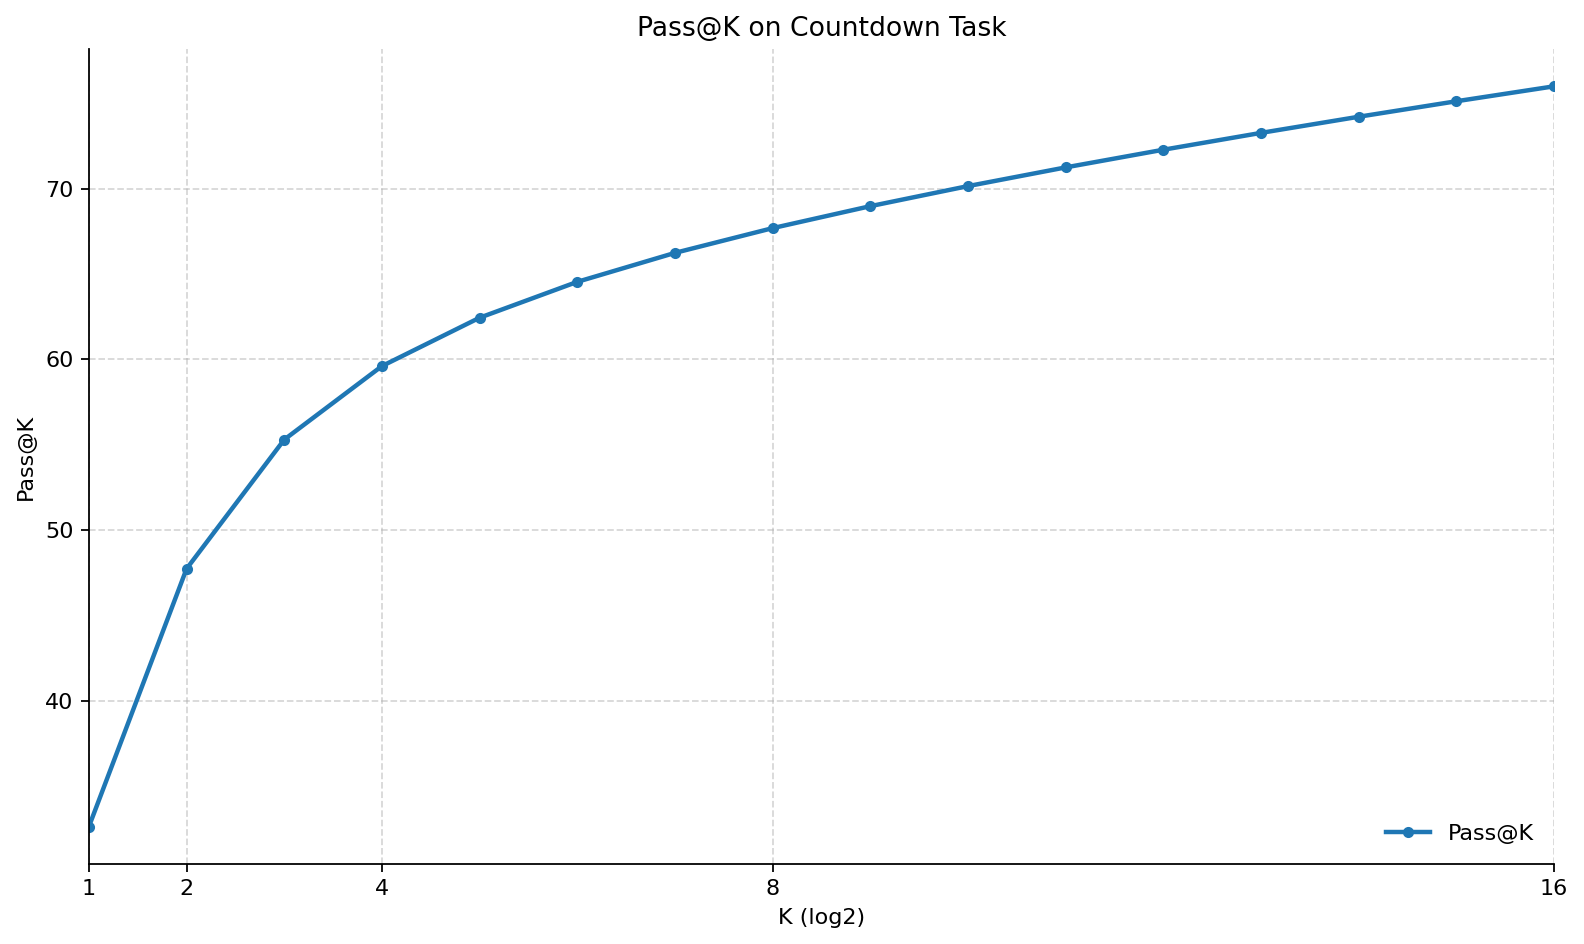

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

k = np.arange(1, len(pass_at_k_values) + 1)

# Create a figure for the plot
fig, ax = plt.subplots(figsize=(10, 6), dpi=160)

ax.plot(k, pass_at_k_values * 100, marker="o", markersize=4, linewidth=2, label="Pass@K")

ax.set_xlabel("K (log2)")
ax.set_ylabel("Pass@K")
ax.set_title("Pass@K on Countdown Task")
ax.set_xlim(1, k[-1])

major_ticks = [t for t in [1, 2, 4, 8, 16] if t <= k[-1]]
ax.xaxis.set_major_locator(FixedLocator(major_ticks))
ax.set_xticklabels([str(t) for t in major_ticks])

ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()